# Renewable Energy, Economic Growth and CO₂ Emissions (2015–2024)

## Economic Theory

This project is motivated by the Environmental Kuznets Curve (EKC) and Green Economic Growth Theory. The analysis examines whether renewable energy consumption(REC) contributes to lower carbon dioxide (CO₂) emissions while supporting economic growth (GDP), and whether these relationships differ between developed and developing economies.

## Project Overview
This project investigates the relationship between REC, GDP, and CO2 emissions across nine developed and developing countries between 2015 and 2024. Using Python, the analysis follows a complete data analytics workflow including data cleaning, exploratory data analysis (EDA), feature engineering, statistical analysis, machine learning, and data visualization.

## Objectives
- Explore trends in REC, GDP, and CO₂
- Compare developed and developing countries
- Examine relationships among key variables
- Build a multiple linear regression model to predict CO₂
- Evaluate model performance using machine learning metrics

## Section 1: Import Required Libraries
Import the necessary libraries for data manipulation, visualization, machine learning, and econometric analysis.

In [1]:
# Section 1: Import Required Libraries
# Pandas and NumPy for data manipulation
import pandas as pd
import numpy as np

# Matplotlib and Seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statsmodels for econometric analysis
import statsmodels.api as sm

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Load and Preview Dataset
Load the dataset containing annual observations for REC, GDP, and CO₂ from 2015 to 2024 across nine countries. Data source: World Bank Development Indicators (WDI)

In [2]:
# Section 2: Load and Preview Dataset
# Load the dataset from CSV file
df = pd.read_csv(r"D:\DATA\Project1.csv")

# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

First 5 rows of the dataset:


,CN,YR,REC,GDP,CO2
0,Aus,2015,8.3,2.16,16.82
1,Aus,2016,9.2,2.76,16.89
2,Aus,2017,9.3,2.29,16.72
3,Aus,2018,9.4,2.87,16.39
4,Aus,2019,9.6,2.19,16.10



Dataset shape: 90 rows × 5 columns


## Section 3: Data Overview and Structure
Generate descriptive statistics to understand dataset dimensions, data types, memory usage, and variable names.

In [3]:
# Section 3: Data Overview and Structure
# Display dataset info: data types, non-null values, memory usage
print("Dataset Information:")
print("-" * 50)
df.info()

print("\n" + "=" * 50)
print("Descriptive Statistics:")
print("-" * 50)
display(df.describe().round(2))

print("\n" + "=" * 50)
print("Column Names:")
print("-" * 50)
print(df.columns.tolist())

Dataset Information:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CN      90 non-null     str    
 1   YR      90 non-null     int64  
 2   REC     90 non-null     float64
 3   GDP     90 non-null     float64
 4   CO2     90 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 3.6 KB

Descriptive Statistics:
--------------------------------------------------


,YR,REC,GDP,CO2
count,90.00,90.00,90.00,90.00
mean,2019.50,14.26,3.42,10.24
std,2.89,10.44,3.55,6.38
min,2015.00,0.10,-10.05,1.68
25%,2017.00,7.55,2.07,4.80
50%,2019.50,11.10,3.64,8.44
75%,2022.00,22.20,5.39,15.46
max,2024.00,36.10,9.69,24.32



Column Names:
--------------------------------------------------
['CN', 'YR', 'REC', 'GDP', 'CO2']


## Section 4: Data Cleaning and Validation
Check for missing values, duplicate records, verify data types, identify the time period range, sort data by country and year, and filter anomalies such as negative GDP values.

In [4]:
# Section 4: Data Cleaning and Validation

# 4.1 Check for missing values
print("4.1 Missing Values Analysis:")
print("-" * 50)
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

print("\n" + "=" * 50)

# 4.2 Check for duplicate records
print("4.2 Duplicate Records Analysis:")
print("-" * 50)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

print("\n" + "=" * 50)

# 4.3 Verify data types
print("4.3 Data Types Verification:")
print("-" * 50)
print(df.dtypes)

print("\n" + "=" * 50)

# 4.4 Identify time period range
print("4.4 Time Period Range:")
print("-" * 50)
print(f"Minimum year: {df['YR'].min()}")
print(f"Maximum year: {df['YR'].max()}")

print("\n" + "=" * 50)

# 4.5 Countries included in dataset
print("4.5 Countries in Dataset:")
print("-" * 50)
countries = df["CN"].unique()
print(f"Number of countries: {len(countries)}")
print(f"Countries: {', '.join(sorted(countries))}")

4.1 Missing Values Analysis:
--------------------------------------------------
CN     0
YR     0
REC    0
GDP    0
CO2    0
dtype: int64

Total missing values: 0

4.2 Duplicate Records Analysis:
--------------------------------------------------
Total duplicate rows: 0

4.3 Data Types Verification:
--------------------------------------------------
CN         str
YR       int64
REC    float64
GDP    float64
CO2    float64
dtype: object

4.4 Time Period Range:
--------------------------------------------------
Minimum year: 2015
Maximum year: 2024

4.5 Countries in Dataset:
--------------------------------------------------
Number of countries: 9
Countries: Aus, Can, China, India, Indonesia, Malaysia, UAE, UK, USA


In [5]:
# 4.6 Sort data by country and year
print("4.6 Data Sorted by Country and Year:")
print("-" * 50)
df_sorted = df.sort_values(["CN", "YR"])
display(df_sorted.head(10))

print("\n" + "=" * 50)

# 4.7 Identify negative GDP values (anomalies)
print("4.7 Negative GDP Values (Anomalies):")
print("-" * 50)
negative_gdp = df[df["GDP"] < 0]
print(f"Observations with negative GDP: {len(negative_gdp)}")
if len(negative_gdp) > 0:
    display(negative_gdp)
    print("\nInterpretation: Negative GDP values primarily correspond to the economic")
    print("downturn during the COVID-19 pandemic (2020) and OPEC-led oil production cuts (2017).")

4.6 Data Sorted by Country and Year:
--------------------------------------------------


,CN,YR,REC,GDP,CO2
0,Aus,2015,8.3,2.16,16.82
1,Aus,2016,9.2,2.76,16.89
2,Aus,2017,9.3,2.29,16.72
3,Aus,2018,9.4,2.87,16.39
4,Aus,2019,9.6,2.19,16.10
5,Aus,2020,9.9,-0.13,15.30
6,Aus,2021,9.8,2.01,14.98
7,Aus,2022,10.3,4.25,14.53
8,Aus,2023,11.2,3.58,14.16
9,Aus,2024,12.3,1.37,14.10



4.7 Negative GDP Values (Anomalies):
--------------------------------------------------
Observations with negative GDP: 9


,CN,YR,REC,GDP,CO2
5,Aus,2020,9.9,-0.13,15.30
15,Can,2020,22.8,-5.04,14.42
35,India,2020,32.5,-5.78,1.68
45,Indonesia,2020,25.2,-2.07,2.17
55,Malaysia,2020,5.2,-5.46,7.47
62,UAE,2017,0.1,-1.06,22.16
65,UAE,2020,0.2,-8.69,20.81
75,UK,2020,8.8,-10.05,4.79
85,USA,2020,9.7,-2.08,13.47



Interpretation: Negative GDP values primarily correspond to the economic
downturn during the COVID-19 pandemic (2020) and OPEC-led oil production cuts (2017).


## Section 5: Exploratory Data Analysis
Calculate average REC, GDP, and CO₂ by country. Create country summary statistics. Rank countries by REC, GDP growth, and CO₂ emissions. Analyze quantile distributions and identify countries above average thresholds.

In [6]:
# Section 5: Exploratory Data Analysis

# 5.1 Overall descriptive statistics
print("5.1 Overall Descriptive Statistics:")
print("-" * 50)
overall_stats = df.describe().round(2)
display(overall_stats)

print("\nInterpretation:")
print("- Average REC: 14.26%, ranging from 0.10% to 36.10%")
print("- Average GDP growth: 3.42%, ranging from -10.05% to 9.69%")
print("- Average CO₂ emissions: 10.24 metric tons per capita, ranging from 1.68 to 24.32")
print("- Large standard deviations indicate significant heterogeneity among countries")

5.1 Overall Descriptive Statistics:
--------------------------------------------------


,YR,REC,GDP,CO2
count,90.00,90.00,90.00,90.00
mean,2019.50,14.26,3.42,10.24
std,2.89,10.44,3.55,6.38
min,2015.00,0.10,-10.05,1.68
25%,2017.00,7.55,2.07,4.80
50%,2019.50,11.10,3.64,8.44
75%,2022.00,22.20,5.39,15.46
max,2024.00,36.10,9.69,24.32



Interpretation:
- Average REC: 14.26%, ranging from 0.10% to 36.10%
- Average GDP growth: 3.42%, ranging from -10.05% to 9.69%
- Average CO₂ emissions: 10.24 metric tons per capita, ranging from 1.68 to 24.32
- Large standard deviations indicate significant heterogeneity among countries


In [7]:
# 5.2 Average Renewable Energy Consumption by Country
print("\n5.2 Average Renewable Energy Consumption (REC) by Country:")
print("-" * 50)
avg_rec = df.groupby("CN")["REC"].mean().sort_values(ascending=False).round(2)
display(avg_rec)

print("\nInterpretation:")
print("- India records the highest average REC (33.99%)")
print("- Indonesia and Canada follow with substantial REC")
print("- UAE has the lowest REC (0.36%), reflecting limited renewable energy adoption")


5.2 Average Renewable Energy Consumption (REC) by Country:
--------------------------------------------------


CN
India        33.99
Indonesia    25.35
Can          22.58
China        13.07
Aus           9.93
USA           9.63
UK            8.76
Malaysia      4.68
UAE           0.36
Name: REC, dtype: float64


Interpretation:
- India records the highest average REC (33.99%)
- Indonesia and Canada follow with substantial REC
- UAE has the lowest REC (0.36%), reflecting limited renewable energy adoption


In [8]:
# 5.3 Average GDP Growth by Country
print("\n5.3 Average GDP Growth by Country:")
print("-" * 50)
avg_gdp = df.groupby("CN")["GDP"].mean().sort_values(ascending=False).round(2)
display(avg_gdp)

print("\nInterpretation:")
print("- India (5.92%) and China (5.79%) experienced strongest average economic growth")
print("- United Kingdom (1.52%) and Canada (1.90%) recorded lower growth rates")
print("- Developing economies generally outpaced developed economies")


5.3 Average GDP Growth by Country:
--------------------------------------------------


CN
India        5.92
China        5.79
Indonesia    4.22
Malaysia     4.01
UAE          2.62
USA          2.51
Aus          2.34
Can          1.90
UK           1.52
Name: GDP, dtype: float64


Interpretation:
- India (5.92%) and China (5.79%) experienced strongest average economic growth
- United Kingdom (1.52%) and Canada (1.90%) recorded lower growth rates
- Developing economies generally outpaced developed economies


In [9]:
# 5.4 Average CO₂ Emissions by Country
print("\n5.4 Average CO₂ Emissions by Country:")
print("-" * 50)
avg_co2 = df.groupby("CN")["CO2"].mean().sort_values(ascending=False).round(2)
display(avg_co2)

print("\nInterpretation:")
print("- UAE records highest average CO₂ emissions (20.89 metric tons per capita)")
print("- Australia, Canada, and USA also exhibit high emissions")
print("- India and Indonesia have lowest emissions among selected countries")


5.4 Average CO₂ Emissions by Country:
--------------------------------------------------


CN
UAE          20.89
Aus          15.60
Can          15.30
USA          14.68
China         8.48
Malaysia      7.79
UK            5.25
Indonesia     2.31
India         1.87
Name: CO2, dtype: float64


Interpretation:
- UAE records highest average CO₂ emissions (20.89 metric tons per capita)
- Australia, Canada, and USA also exhibit high emissions
- India and Indonesia have lowest emissions among selected countries


In [10]:
# 5.5 Country Summary Statistics
print("\n5.5 Comprehensive Country Summary:")
print("-" * 50)
country_summary = df.groupby("CN")[["REC", "GDP", "CO2"]].mean().round(2)
display(country_summary)

print("\nInterpretation:")
print("Comparing all three indicators simultaneously reveals substantial differences")
print("in economic and environmental performance across countries. Nations with")
print("higher renewable energy consumption generally tend to report lower CO₂")
print("emissions and higher economic growth.")


5.5 Comprehensive Country Summary:
--------------------------------------------------


,REC,GDP,CO2
CN,,,
Aus,9.93,2.34,15.60
Can,22.58,1.90,15.30
China,13.07,5.79,8.48
India,33.99,5.92,1.87
Indonesia,25.35,4.22,2.31
Malaysia,4.68,4.01,7.79
UAE,0.36,2.62,20.89
UK,8.76,1.52,5.25
USA,9.63,2.51,14.68



Interpretation:
Comparing all three indicators simultaneously reveals substantial differences
in economic and environmental performance across countries. Nations with
higher renewable energy consumption generally tend to report lower CO₂
emissions and higher economic growth.


In [11]:
# 5.6 Countries ranked by REC
print("\n5.6 Countries Ranked by REC (Highest to Lowest):")
print("-" * 50)
display(country_summary.sort_values("REC", ascending=False))

print("\n5.7 Countries Ranked by GDP Growth (Highest to Lowest):")
print("-" * 50)
display(country_summary.sort_values("GDP", ascending=False))

print("\n5.8 Countries Ranked by CO₂ Emissions (Highest to Lowest):")
print("-" * 50)
display(country_summary.sort_values("CO2", ascending=False))


5.6 Countries Ranked by REC (Highest to Lowest):
--------------------------------------------------


,REC,GDP,CO2
CN,,,
India,33.99,5.92,1.87
Indonesia,25.35,4.22,2.31
Can,22.58,1.90,15.30
China,13.07,5.79,8.48
Aus,9.93,2.34,15.60
USA,9.63,2.51,14.68
UK,8.76,1.52,5.25
Malaysia,4.68,4.01,7.79
UAE,0.36,2.62,20.89



5.7 Countries Ranked by GDP Growth (Highest to Lowest):
--------------------------------------------------


,REC,GDP,CO2
CN,,,
India,33.99,5.92,1.87
China,13.07,5.79,8.48
Indonesia,25.35,4.22,2.31
Malaysia,4.68,4.01,7.79
UAE,0.36,2.62,20.89
USA,9.63,2.51,14.68
Aus,9.93,2.34,15.60
Can,22.58,1.90,15.30
UK,8.76,1.52,5.25



5.8 Countries Ranked by CO₂ Emissions (Highest to Lowest):
--------------------------------------------------


,REC,GDP,CO2
CN,,,
UAE,0.36,2.62,20.89
Aus,9.93,2.34,15.60
Can,22.58,1.90,15.30
USA,9.63,2.51,14.68
China,13.07,5.79,8.48
Malaysia,4.68,4.01,7.79
UK,8.76,1.52,5.25
Indonesia,25.35,4.22,2.31
India,33.99,5.92,1.87


In [12]:
# 5.9 Additional Descriptive Statistics
print("\n5.9 Additional Descriptive Statistics:")
print("-" * 50)

print("\nMaximum Values:")
display(df.max(numeric_only=True))

print("\nMinimum Values:")
display(df.min(numeric_only=True))

print("\nStandard Deviation:")
display(df.std(numeric_only=True).round(2))

print("\nVariance:")
display(df.var(numeric_only=True).round(2))


5.9 Additional Descriptive Statistics:
--------------------------------------------------

Maximum Values:


YR     2024.00
REC      36.10
GDP       9.69
CO2      24.32
dtype: float64


Minimum Values:


YR     2015.00
REC       0.10
GDP     -10.05
CO2       1.68
dtype: float64


Standard Deviation:


YR      2.89
REC    10.44
GDP     3.55
CO2     6.38
dtype: float64


Variance:


YR       8.34
REC    109.01
GDP     12.57
CO2     40.66
dtype: float64

In [13]:
# 5.10 Quantile Analysis
print("\n5.10 Quantile Analysis (25th, 50th, 75th percentiles):")
print("-" * 50)
quantile_analysis = df.quantile([0.25, 0.50, 0.75], numeric_only=True).round(2)
display(quantile_analysis)

print("\nInterpretation:")
print("- Median REC: 11.10% (25th percentile: 7.55%, 75th percentile: 22.20%)")
print("- Median GDP: 3.64% (25th percentile: 2.71%, 75th percentile: 5.13%)")
print("- Median CO₂: 8.44 metric tons (25th percentile: 4.80, 75th percentile: 15.46)")
print("- Wide gaps between percentiles highlight substantial differences among countries")


5.10 Quantile Analysis (25th, 50th, 75th percentiles):
--------------------------------------------------


,YR,REC,GDP,CO2
0.25,2017.0,7.55,2.07,4.80
0.50,2019.5,11.10,3.64,8.44
0.75,2022.0,22.20,5.39,15.46



Interpretation:
- Median REC: 11.10% (25th percentile: 7.55%, 75th percentile: 22.20%)
- Median GDP: 3.64% (25th percentile: 2.71%, 75th percentile: 5.13%)
- Median CO₂: 8.44 metric tons (25th percentile: 4.80, 75th percentile: 15.46)
- Wide gaps between percentiles highlight substantial differences among countries


## Section 6: Correlation and Statistical Analysis
Calculate the correlation matrix to measure relationships among REC, GDP, and CO₂. Interpret correlation coefficients to understand variable dependencies.

In [14]:
# Section 6: Correlation and Statistical Analysis

# 6.1 Calculate correlation matrix
print("6.1 Correlation Matrix:")
print("-" * 50)
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix.round(3))

print("\nInterpretation:")
print("- REC vs CO₂: r = -0.60 (moderately strong negative correlation)")
print("  → Higher REC is associated with lower CO₂ emissions")
print("\n- GDP vs CO₂: r = -0.24 (weak negative correlation)")
print("  → Economic growth alone has limited relationship with CO₂ emissions")
print("\n- REC vs GDP: r = 0.21 (weak positive correlation)")
print("  → Countries with higher REC tend to experience slightly stronger economic growth")

6.1 Correlation Matrix:
--------------------------------------------------


,YR,REC,GDP,CO2
YR,1.000,0.051,-0.012,-0.069
REC,0.051,1.000,0.210,-0.598
GDP,-0.012,0.210,1.000,-0.235
CO2,-0.069,-0.598,-0.235,1.000



Interpretation:
- REC vs CO₂: r = -0.60 (moderately strong negative correlation)
  → Higher REC is associated with lower CO₂ emissions

- GDP vs CO₂: r = -0.24 (weak negative correlation)
  → Economic growth alone has limited relationship with CO₂ emissions

- REC vs GDP: r = 0.21 (weak positive correlation)
  → Countries with higher REC tend to experience slightly stronger economic growth


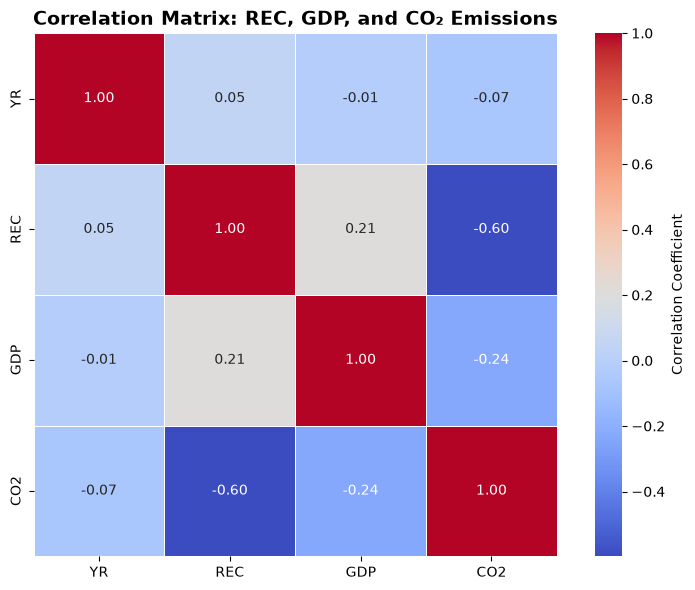

In [15]:
# 6.2 Visualize correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation Matrix: REC, GDP, and CO₂ Emissions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 7: Data Visualization
Create visualizations including bar charts for average REC/GDP/CO₂ by country, and a scatter plot showing the relationship between REC and CO₂ emissions.

7.1 Average Renewable Energy Consumption by Country
--------------------------------------------------


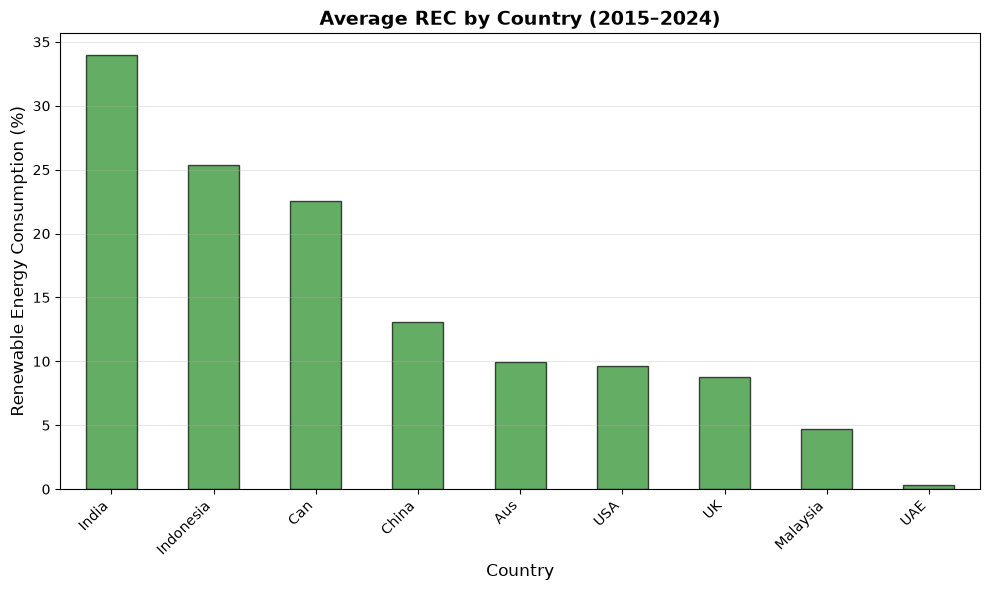


Interpretation:
India leads in renewable energy adoption (33.99%), followed by Indonesia and Canada.
UAE exhibits the lowest REC, highlighting varying energy transition trajectories.


In [16]:
# Section 7: Visual Analysis

# 7.1 Average REC by Country (Bar Chart)
print("7.1 Average Renewable Energy Consumption by Country")
print("-" * 50)

rec_by_country = df.groupby("CN")["REC"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rec_by_country.plot(kind="bar", color="forestgreen", edgecolor="black", alpha=0.7)
plt.title("Average REC by Country (2015–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Renewable Energy Consumption (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("India leads in renewable energy adoption (33.99%), followed by Indonesia and Canada.")
print("UAE exhibits the lowest REC, highlighting varying energy transition trajectories.")


7.2 Average GDP Growth by Country
--------------------------------------------------


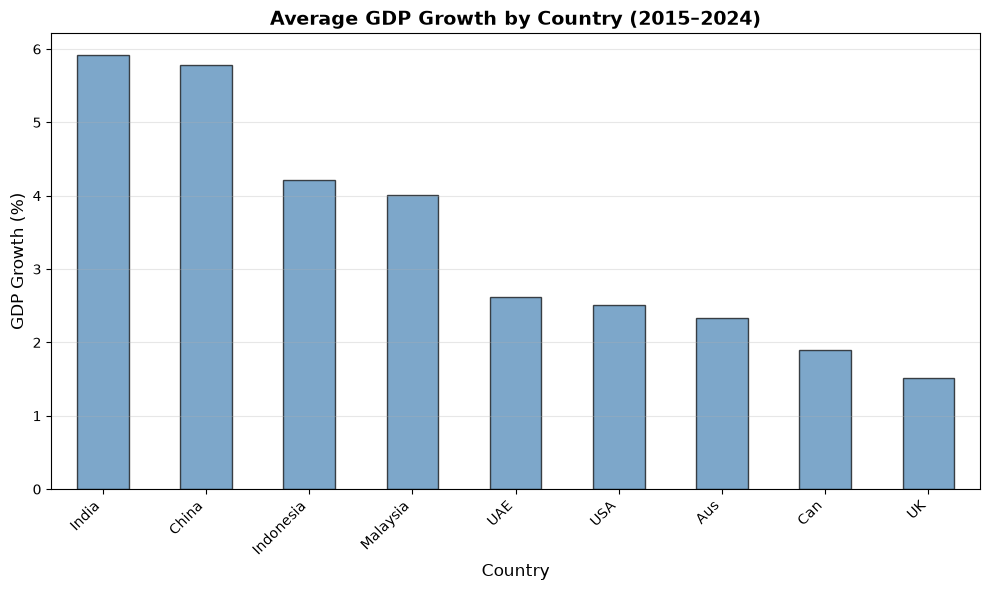


Interpretation:
India and China experienced the strongest average GDP growth (5.92% and 5.79%).
Developed economies like UK and Canada recorded lower growth rates.


In [17]:
# 7.2 Average GDP Growth by Country (Bar Chart)
print("\n7.2 Average GDP Growth by Country")
print("-" * 50)

gdp_by_country = df.groupby("CN")["GDP"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
gdp_by_country.plot(kind="bar", color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Average GDP Growth by Country (2015–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("GDP Growth (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("India and China experienced the strongest average GDP growth (5.92% and 5.79%).")
print("Developed economies like UK and Canada recorded lower growth rates.")


7.3 Average CO₂ Emissions by Country
--------------------------------------------------


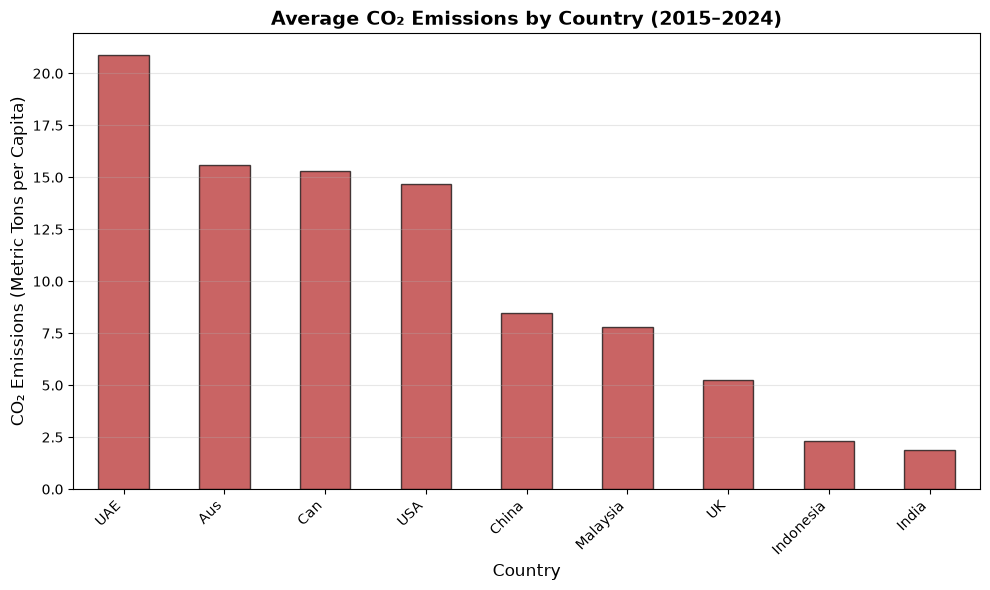


Interpretation:
UAE shows the highest emissions (20.89 metric tons per capita).
India and Indonesia maintain the lowest emissions despite development activities.


In [18]:
# 7.3 Average CO₂ Emissions by Country (Bar Chart)
print("\n7.3 Average CO₂ Emissions by Country")
print("-" * 50)

co2_by_country = df.groupby("CN")["CO2"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
co2_by_country.plot(kind="bar", color="firebrick", edgecolor="black", alpha=0.7)
plt.title("Average CO₂ Emissions by Country (2015–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("CO₂ Emissions (Metric Tons per Capita)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("UAE shows the highest emissions (20.89 metric tons per capita).")
print("India and Indonesia maintain the lowest emissions despite development activities.")


7.4 Relationship Between REC and CO₂ Emissions
--------------------------------------------------


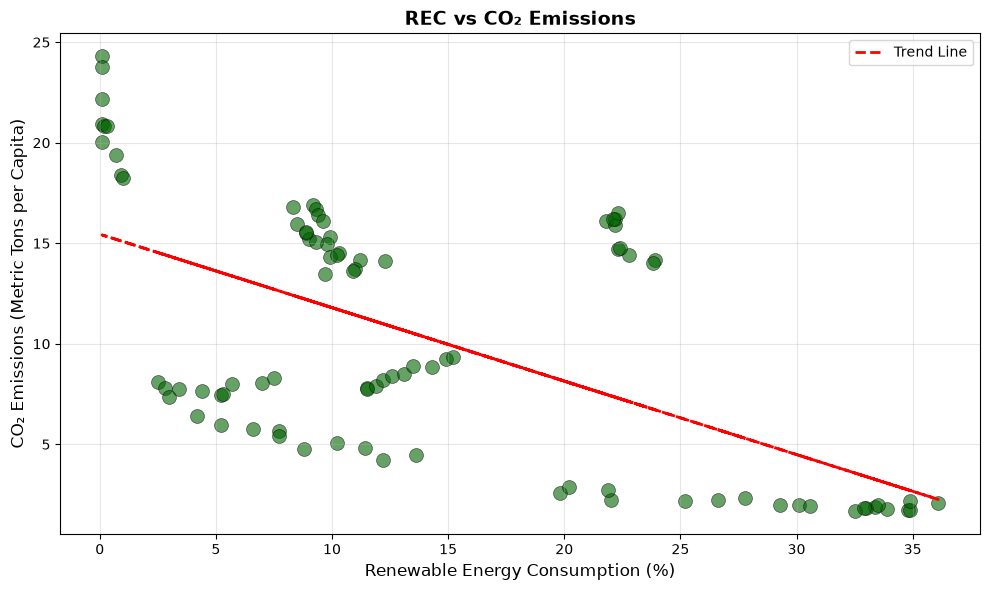


Interpretation:
Clear negative relationship: Higher REC is associated with lower CO₂ emissions.
This confirms the correlation analysis findings (r = -0.60).


In [19]:
# 7.4 REC vs CO₂ Emissions Scatter Plot
print("\n7.4 Relationship Between REC and CO₂ Emissions")
print("-" * 50)

plt.figure(figsize=(10, 6))

plt.scatter(
    df["REC"],
    df["CO2"],
    color="darkgreen",
    alpha=0.6,
    s=100,
    edgecolors="black",
    linewidth=0.5
)

# Add trend line
z = np.polyfit(df["REC"], df["CO2"], 1)
p = np.poly1d(z)
plt.plot(df["REC"], p(df["REC"]), "r--", linewidth=2, label="Trend Line")

plt.title("REC vs CO₂ Emissions", fontsize=14, fontweight="bold")
plt.xlabel("Renewable Energy Consumption (%)", fontsize=12)
plt.ylabel("CO₂ Emissions (Metric Tons per Capita)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Clear negative relationship: Higher REC is associated with lower CO₂ emissions.")
print("This confirms the correlation analysis findings (r = -0.60).")

## Section 8: Linear Regression Model
Define features (REC, GDP) and target variable (CO₂). Split dataset into 80% training and 20% testing sets. Train LinearRegression model and calculate regression coefficients.

In [20]:
# Section 8: Linear Regression Model

# 8.1 Define Features and Target Variables
print("8.1 Define Features and Target Variables")
print("-" * 50)

X = df[["REC", "GDP"]]  # Explanatory variables
y = df["CO2"]           # Target variable

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFirst 5 observations of features (X):")
display(X.head())
print(f"\nFirst 5 observations of target (y):")
display(y.head())

8.1 Define Features and Target Variables
--------------------------------------------------
Features (X) shape: (90, 2)
Target (y) shape: (90,)

First 5 observations of features (X):


,REC,GDP
0,8.3,2.16
1,9.2,2.76
2,9.3,2.29
3,9.4,2.87
4,9.6,2.19



First 5 observations of target (y):


0    16.82
1    16.89
2    16.72
3    16.39
4    16.10
Name: CO2, dtype: float64

In [21]:
# 8.2 Split the Dataset
print("\n8.2 Train-Test Split (80%-20%)")
print("-" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Training set size: {len(X_train)} observations (80%)")
print(f"Testing set size: {len(X_test)} observations (20%)")
print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


8.2 Train-Test Split (80%-20%)
--------------------------------------------------
Training set size: 72 observations (80%)
Testing set size: 18 observations (20%)

Training features shape: (72, 2)
Testing features shape: (18, 2)


In [22]:
# 8.3 Train the Linear Regression Model
print("\n8.3 Train Linear Regression Model")
print("-" * 50)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nModel intercept: {model.intercept_:.4f}")
print(f"Model coefficients:\n  - REC coefficient: {model.coef_[0]:.4f}")
print(f"  - GDP coefficient: {model.coef_[1]:.4f}")


8.3 Train Linear Regression Model
--------------------------------------------------
Model trained successfully!

Model intercept: 16.1126
Model coefficients:
  - REC coefficient: -0.3675
  - GDP coefficient: -0.2138


In [23]:
# 8.4 Regression Equation and Interpretation
print("\n8.4 Regression Equation and Interpretation")
print("-" * 50)

intercept = model.intercept_
coef_rec = model.coef_[0]
coef_gdp = model.coef_[1]

print(f"\nRegression Equation:")
print(f"CO₂ = {intercept:.2f} + {coef_rec:.3f}×REC + {coef_gdp:.3f}×GDP")

print(f"\nCoefficient Interpretation:")
print(f"\nIntercept ({intercept:.2f}):")
print(f"  - Predicted CO₂ emissions when REC and GDP growth are zero")

print(f"\nREC Coefficient ({coef_rec:.3f}):")
print(f"  - A 1% increase in REC is associated with a {abs(coef_rec):.3f}-unit decrease in CO₂")
print(f"  - Negative coefficient indicates renewable energy reduces emissions")

print(f"\nGDP Coefficient ({coef_gdp:.3f}):")
print(f"  - A 1% increase in GDP growth is associated with a {abs(coef_gdp):.3f}-unit decrease in CO₂")
print(f"  - Negative coefficient suggests economic growth is associated with lower emissions")

print(f"\nOverall Interpretation:")
print(f"Both REC and GDP growth show negative relationships with CO₂ emissions,")
print(f"suggesting that renewable energy expansion and economic growth contribute to")
print(f"lower carbon emissions in the sample.")


8.4 Regression Equation and Interpretation
--------------------------------------------------

Regression Equation:
CO₂ = 16.11 + -0.368×REC + -0.214×GDP

Coefficient Interpretation:

Intercept (16.11):
  - Predicted CO₂ emissions when REC and GDP growth are zero

REC Coefficient (-0.368):
  - A 1% increase in REC is associated with a 0.368-unit decrease in CO₂
  - Negative coefficient indicates renewable energy reduces emissions

GDP Coefficient (-0.214):
  - A 1% increase in GDP growth is associated with a 0.214-unit decrease in CO₂
  - Negative coefficient suggests economic growth is associated with lower emissions

Overall Interpretation:
Both REC and GDP growth show negative relationships with CO₂ emissions,
suggesting that renewable energy expansion and economic growth contribute to
lower carbon emissions in the sample.


In [24]:
# 8.5 Make Predictions
print("\n8.5 Generate Predictions on Test Set")
print("-" * 50)

y_pred = model.predict(X_test)

print(f"Predictions generated for {len(y_pred)} test observations")
print(f"\nFirst 10 predictions:")
predictions_display = pd.DataFrame({
    "Actual CO₂": y_test.values[:10],
    "Predicted CO₂": y_pred[:10],
    "Difference": (y_test.values[:10] - y_pred[:10])
})
display(predictions_display.round(2))


8.5 Generate Predictions on Test Set
--------------------------------------------------
Predictions generated for 18 test observations

First 10 predictions:


,Actual CO₂,Predicted CO₂,Difference
0,1.96,4.01,-2.05
1,7.88,10.27,-2.39
2,7.47,15.37,-7.90
3,6.39,14.11,-7.72
4,16.82,12.60,4.22
5,8.89,9.32,-0.43
6,2.17,1.77,0.40
7,20.81,17.90,2.91
8,16.09,7.96,8.13
9,2.34,4.82,-2.48


## Section 9: Model Performance Evaluation
Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score. Create scatter plot comparing actual vs predicted CO₂ emissions.

In [25]:
# Section 9: Model Performance Evaluation

# 9.1 Calculate Performance Metrics
print("9.1 Model Performance Metrics")
print("-" * 50)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE):        {mae:.3f} metric tons")
print(f"Mean Squared Error (MSE):         {mse:.3f}")
print(f"Root Mean Squared Error (RMSE):   {rmse:.3f} metric tons")
print(f"R² Score (Coefficient of Determination): {r2:.3f}")

print(f"\nInterpretation:")
print(f"- MAE of {mae:.2f} means predictions differ by ~{mae:.2f} units on average")
print(f"- RMSE of {rmse:.2f} indicates moderate prediction errors")
print(f"- R² of {r2:.3f} means the model explains {r2*100:.1f}% of CO₂ variation")
print(f"- Additional explanatory variables may improve predictive performance")

9.1 Model Performance Metrics
--------------------------------------------------
Mean Absolute Error (MAE):        4.160 metric tons
Mean Squared Error (MSE):         24.820
Root Mean Squared Error (RMSE):   4.982 metric tons
R² Score (Coefficient of Determination): 0.287

Interpretation:
- MAE of 4.16 means predictions differ by ~4.16 units on average
- RMSE of 4.98 indicates moderate prediction errors
- R² of 0.287 means the model explains 28.7% of CO₂ variation
- Additional explanatory variables may improve predictive performance



9.2 Actual vs Predicted CO₂ Emissions
--------------------------------------------------


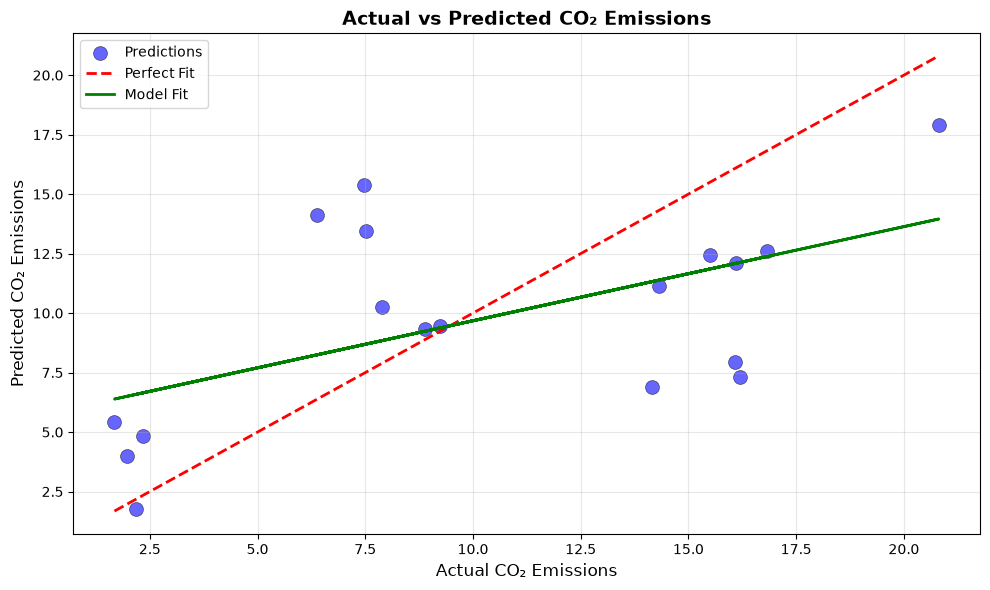


Interpretation:
Most observations cluster near the trend line, indicating reasonable predictions.
Some observations deviate from the perfect fit line, showing prediction errors.


In [26]:
# 9.2 Actual vs Predicted Scatter Plot
print("\n9.2 Actual vs Predicted CO₂ Emissions")
print("-" * 50)

plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(
    y_test,
    y_pred,
    color="blue",
    alpha=0.6,
    s=100,
    edgecolors="black",
    linewidth=0.5,
    label="Predictions"
)

# Perfect prediction line (45-degree line)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Fit")

# Trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), 'g-', linewidth=2, label="Model Fit")

plt.xlabel("Actual CO₂ Emissions", fontsize=12)
plt.ylabel("Predicted CO₂ Emissions", fontsize=12)
plt.title("Actual vs Predicted CO₂ Emissions", fontsize=14, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Most observations cluster near the trend line, indicating reasonable predictions.")
print("Some observations deviate from the perfect fit line, showing prediction errors.")

## Section 10: Developed vs. Developing Country Comparison
Classify countries into developed and developing groups. Train separate LinearRegression models for each group and compare regression coefficients using OLS regression.

In [27]:
# Section 10: Developed vs. Developing Country Comparison

# 10.1 Classify Countries
print("10.1 Country Classification")
print("-" * 50)

developed_countries = ["Aus", "Can", "UK", "USA"]

df["Group"] = df["CN"].apply(
    lambda x: "Developed" if x in developed_countries else "Developing"
)

developed = df[df["Group"] == "Developed"]
developing = df[df["Group"] == "Developing"]

print(f"Developed countries: {', '.join(sorted(developed['CN'].unique()))}")
print(f"Developing countries: {', '.join(sorted(developing['CN'].unique()))}")
print(f"\nDeveloped observations: {len(developed)} (out of {len(df)})")
print(f"Developing observations: {len(developing)} (out of {len(df)})")

10.1 Country Classification
--------------------------------------------------
Developed countries: Aus, Can, UK, USA
Developing countries: China, India, Indonesia, Malaysia, UAE

Developed observations: 40 (out of 90)
Developing observations: 50 (out of 90)


In [28]:
# 10.2 Regression Model for Developed Countries
print("\n10.2 Regression Model: Developed Countries")
print("-" * 50)

X_dev = developed[["REC", "GDP"]]
y_dev = developed["CO2"]

model_dev = LinearRegression()
model_dev.fit(X_dev, y_dev)

r2_dev = model_dev.score(X_dev, y_dev)

print(f"Intercept: {model_dev.intercept_:.4f}")
print(f"REC Coefficient: {model_dev.coef_[0]:+.4f}")
print(f"GDP Coefficient: {model_dev.coef_[1]:+.4f}")
print(f"R² Score: {r2_dev:.3f}")

print(f"\nInterpretation:")
print(f"- REC has a POSITIVE coefficient ({model_dev.coef_[0]:.3f})")
print(f"  → Unexpectedly, higher REC is associated with higher CO₂ in developed countries")
print(f"- GDP has a POSITIVE coefficient ({model_dev.coef_[1]:.3f})")
print(f"  → Economic growth is associated with higher emissions")
print(f"- Low R² ({r2_dev:.3f}) suggests limited explanatory power")
print(f"- Additional factors not captured in this model influence CO₂ in developed nations")


10.2 Regression Model: Developed Countries
--------------------------------------------------
Intercept: 8.9210
REC Coefficient: +0.2642
GDP Coefficient: +0.2049
R² Score: 0.143

Interpretation:
- REC has a POSITIVE coefficient (0.264)
  → Unexpectedly, higher REC is associated with higher CO₂ in developed countries
- GDP has a POSITIVE coefficient (0.205)
  → Economic growth is associated with higher emissions
- Low R² (0.143) suggests limited explanatory power
- Additional factors not captured in this model influence CO₂ in developed nations


In [29]:
# 10.3 Regression Model for Developing Countries
print("\n10.3 Regression Model: Developing Countries")
print("-" * 50)

X_deving = developing[["REC", "GDP"]]
y_deving = developing["CO2"]

model_deving = LinearRegression()
model_deving.fit(X_deving, y_deving)

r2_deving = model_deving.score(X_deving, y_deving)

print(f"Intercept: {model_deving.intercept_:.4f}")
print(f"REC Coefficient: {model_deving.coef_[0]:+.4f}")
print(f"GDP Coefficient: {model_deving.coef_[1]:+.4f}")
print(f"R² Score: {r2_deving:.3f}")

print(f"\nInterpretation:")
print(f"- REC has a NEGATIVE coefficient ({model_deving.coef_[0]:.3f})")
print(f"  → Higher REC is associated with lower CO₂ emissions")
print(f"- GDP has a NEGATIVE coefficient ({model_deving.coef_[1]:.3f})")
print(f"  → Economic growth is associated with lower emissions")
print(f"- High R² ({r2_deving:.3f}) indicates strong explanatory power")
print(f"- Model captures relationships in developing countries much better")


10.3 Regression Model: Developing Countries
--------------------------------------------------
Intercept: 15.4802
REC Coefficient: -0.4430
GDP Coefficient: -0.0776
R² Score: 0.681

Interpretation:
- REC has a NEGATIVE coefficient (-0.443)
  → Higher REC is associated with lower CO₂ emissions
- GDP has a NEGATIVE coefficient (-0.078)
  → Economic growth is associated with lower emissions
- High R² (0.681) indicates strong explanatory power
- Model captures relationships in developing countries much better


In [30]:
# 10.4 Comparison Summary
print("\n10.4 Model Comparison: Developed vs Developing Countries")
print("-" * 50)

comparison_df = pd.DataFrame({
    "Metric": ["REC Coefficient", "GDP Coefficient", "R² Score", "Observations"],
    "Developed": [
        f"{model_dev.coef_[0]:+.3f}",
        f"{model_dev.coef_[1]:+.3f}",
        f"{r2_dev:.3f}",
        f"{len(developed)}"
    ],
    "Developing": [
        f"{model_deving.coef_[0]:+.3f}",
        f"{model_deving.coef_[1]:+.3f}",
        f"{r2_deving:.3f}",
        f"{len(developing)}"
    ]
})

display(comparison_df)

print(f"\nKey Differences:")
print(f"1. REC direction: Positive (developed) vs Negative (developing)")
print(f"2. Model fit: R² of {r2_dev:.1%} vs {r2_deving:.1%}")
print(f"3. REC is a stronger predictor in developing countries")


10.4 Model Comparison: Developed vs Developing Countries
--------------------------------------------------


,Metric,Developed,Developing
0,REC Coefficient,+0.264,-0.443
1,GDP Coefficient,+0.205,-0.078
2,R² Score,0.143,0.681
3,Observations,40,50



Key Differences:
1. REC direction: Positive (developed) vs Negative (developing)
2. Model fit: R² of 14.3% vs 68.1%
3. REC is a stronger predictor in developing countries


In [31]:
# 10.5 OLS Regression - Developed Countries
print("\n10.5 OLS Regression Analysis: Developed Countries")
print("=" * 70)

X_dev_ols = developed[["REC", "GDP"]]
X_dev_ols = sm.add_constant(X_dev_ols)
y_dev_ols = developed["CO2"]

ols_dev = sm.OLS(y_dev_ols, X_dev_ols).fit()
print(ols_dev.summary())

print("\nInterpretation:")
print(f"- R² = {ols_dev.rsquared:.3f}: Model explains {ols_dev.rsquared*100:.1f}% of variation")
print(f"- Prob(F-statistic) = {ols_dev.f_pvalue:.3f}: Model is marginally significant (p ≈ 0.058)")
print(f"- REC coefficient is statistically significant (p = 0.025)")
print(f"- GDP coefficient is not statistically significant (p = 0.385)")


10.5 OLS Regression Analysis: Developed Countries
                            OLS Regression Results                            
Dep. Variable:                    CO2   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     3.077
Date:                Sun, 19 Jul 2026   Prob (F-statistic):             0.0580
Time:                        17:37:33   Log-Likelihood:                -113.02
No. Observations:                  40   AIC:                             232.0
Df Residuals:                      37   BIC:                             237.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

In [32]:
# 10.6 OLS Regression - Developing Countries
print("\n10.6 OLS Regression Analysis: Developing Countries")
print("=" * 70)

X_deving_ols = developing[["REC", "GDP"]]
X_deving_ols = sm.add_constant(X_deving_ols)
y_deving_ols = developing["CO2"]

ols_deving = sm.OLS(y_deving_ols, X_deving_ols).fit()
print(ols_deving.summary())

print("\nInterpretation:")
print(f"- R² = {ols_deving.rsquared:.3f}: Model explains {ols_deving.rsquared*100:.1f}% of variation")
print(f"- Prob(F-statistic) < 0.001: Model is highly significant")
print(f"- REC coefficient is highly statistically significant (p < 0.001)")
print(f"- REC emerges as the primary determinant of CO₂ in developing countries")
print(f"- GDP coefficient is not statistically significant (p = 0.636)")


10.6 OLS Regression Analysis: Developing Countries
                            OLS Regression Results                            
Dep. Variable:                    CO2   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     50.07
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           2.25e-12
Time:                        17:37:38   Log-Likelihood:                -139.23
No. Observations:                  50   AIC:                             284.5
Df Residuals:                      47   BIC:                             290.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


## Section 11: Residual Analysis and Diagnostics
Calculate residuals as difference between actual and predicted values. Identify observations with largest prediction errors and assess model accuracy limitations.

In [ ]:
# Section 11: Residual Analysis and Diagnostics

# 11.1 Calculate Residuals
print("11.1 Residual Analysis")
print("-" * 50)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison["Residual"] = comparison["Actual"] - comparison["Predicted"]
comparison["Absolute Error"] = abs(comparison["Residual"])

print(f"First 10 observations - Actual vs Predicted vs Residuals:")
display(comparison.head(10).round(3))

print(f"\nResidual Statistics:")
print(f"Mean Residual: {comparison['Residual'].mean():.4f}")
print(f"Std Dev of Residuals: {comparison['Residual'].std():.4f}")
print(f"Min Residual: {comparison['Residual'].min():.4f}")
print(f"Max Residual: {comparison['Residual'].max():.4f}")

In [ ]:
# 11.2 Identify Largest Prediction Errors
print("\n11.2 Observations with Largest Prediction Errors")
print("-" * 50)

largest_errors = comparison.sort_values(
    "Absolute Error",
    ascending=False
).head(8)

display(largest_errors.round(3))

print(f"\nInterpretation:")
print(f"- Largest absolute error: {largest_errors['Absolute Error'].iloc[0]:.2f} metric tons")
print(f"- Model underestimated CO₂ emissions by {largest_errors[largest_errors['Residual'] > 0]['Residual'].max():.2f} at most")
print(f"- Model overestimated CO₂ emissions by {abs(largest_errors[largest_errors['Residual'] < 0]['Residual'].min()):.2f} at most")
print(f"- These outliers suggest model limitations for extreme observations")

In [ ]:
# 11.3 Residual Distribution
print("\n11.3 Residual Distribution Analysis")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(comparison["Residual"], bins=10, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].axvline(comparison["Residual"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {comparison['Residual'].mean():.3f}")
axes[0].set_xlabel("Residual Value", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].set_title("Distribution of Residuals", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Residuals vs Predicted Values
axes[1].scatter(comparison["Predicted"], comparison["Residual"], color="green", alpha=0.6, s=100, edgecolors="black", linewidth=0.5)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted CO₂ Emissions", fontsize=11)
axes[1].set_ylabel("Residuals", fontsize=11)
axes[1].set_title("Residuals vs Predicted Values", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"- Residuals approximately centered around zero (mean ≈ {comparison['Residual'].mean():.3f})")
print(f"- Some right skew suggests occasional positive underestimations")
print(f"- Residuals scatter around zero with no clear pattern (good sign)")

In [ ]:
# 11.4 Positive and Negative Residuals Analysis
print("\n11.4 Positive vs Negative Residuals")
print("-" * 50)

positive_residuals = comparison[comparison["Residual"] > 0]
negative_residuals = comparison[comparison["Residual"] < 0]

print(f"Positive Residuals (Model Underestimation):")
print(f"  Count: {len(positive_residuals)} observations ({len(positive_residuals)/len(comparison)*100:.1f}%)")
print(f"  Mean: {positive_residuals['Residual'].mean():.3f}")
print(f"  Max: {positive_residuals['Residual'].max():.3f}")

print(f"\nNegative Residuals (Model Overestimation):")
print(f"  Count: {len(negative_residuals)} observations ({len(negative_residuals)/len(comparison)*100:.1f}%)")
print(f"  Mean: {negative_residuals['Residual'].mean():.3f}")
print(f"  Min: {negative_residuals['Residual'].min():.3f}")

print(f"\nInterpretation:")
print(f"- Relatively balanced distribution of positive and negative residuals")
print(f"- Model shows no systematic bias toward overestimation or underestimation")
print(f"- Remaining prediction errors suggest need for additional explanatory variables")

## Section 12: Export Cleaned Dataset
Export the processed and validated dataset to CSV format for future reference and downstream analysis.

In [ ]:
# Section 12: Export Cleaned Dataset

# 12.1 Add group classification to main dataframe
print("12.1 Export Cleaned and Processed Dataset")
print("-" * 50)

# Ensure main dataframe has Group column
if "Group" not in df.columns:
    df["Group"] = df["CN"].apply(
        lambda x: "Developed" if x in ["Aus", "Can", "UK", "USA"] else "Developing"
    )

# Export to CSV
output_file = r"d:\Renewable energy Analytics\Renewable_Energy_CO2_Analysis_Cleaned.csv"
df.to_csv(output_file, index=False)

print(f"Dataset exported successfully!")
print(f"Output file: {output_file}")
print(f"Records exported: {len(df)}")
print(f"Columns: {', '.join(df.columns.tolist())}")

print(f"\nDataset Summary:")
print(f"- Total observations: {len(df)}")
print(f"- Countries: {df['CN'].nunique()}")
print(f"- Years: {df['YR'].min()}-{df['YR'].max()}")
print(f"- Group distribution: {df['Group'].value_counts().to_dict()}")

## Section 13: Key Findings and Policy Recommendations
Summarize the main findings from the analysis and highlight the policy implications for renewable energy adoption and sustainable economic growth.

### Key Findings
- Renewable energy consumption is negatively associated with CO₂ emissions.
- GDP growth shows a weaker relationship with emissions than REC.
- The relationship is stronger in developing countries than in developed countries.

### Policy Recommendations
- Increase investment in solar, wind, and other renewable technologies.
- Strengthen policy support for clean energy adoption.
- Promote green finance and international cooperation for sustainable development.

## Final Interpretation and Conclusion
This notebook shows that renewable energy consumption is closely linked to lower CO₂ emissions, while the role of GDP appears weaker and more context-dependent. The results support the idea that energy transition and cleaner technologies can contribute to more sustainable economic growth, especially in developing economies.